# Install

In [1]:
!pip install nltk
!pip install optuna

  Using cached alembic-1.18.4-py3-none-any.whl.metadata (7.2 kB)
  Using cached colorlog-6.10.1-py3-none-any.whl.metadata (11 kB)
  Using cached sqlalchemy-2.0.48-cp310-cp310-win_amd64.whl.metadata (9.8 kB)
  Using cached mako-1.3.10-py3-none-any.whl.metadata (2.9 kB)
  Using cached tomli-2.4.0-py3-none-any.whl.metadata (10 kB)
  Using cached greenlet-3.3.2-cp310-cp310-win_amd64.whl.metadata (3.8 kB)
Using cached alembic-1.18.4-py3-none-any.whl (263 kB)
Using cached sqlalchemy-2.0.48-cp310-cp310-win_amd64.whl (2.1 MB)
Using cached greenlet-3.3.2-cp310-cp310-win_amd64.whl (230 kB)
Using cached colorlog-6.10.1-py3-none-any.whl (11 kB)
Using cached mako-1.3.10-py3-none-any.whl (78 kB)
Using cached tomli-2.4.0-py3-none-any.whl (14 kB)

   ----- ---------------------------------- 1/7 [Mako]
   ----- ---------------------------------- 1/7 [Mako]
   ----- ---------------------------------- 1/7 [Mako]
   ----- ---------------------------------- 1/7 [Mako]
   ----- -----------------------------

# Import

In [1]:
# Importation des différentes librairies, classes et fonctions utiles

# Suppression des warnings de Scikit-Learn liés aux futures versions
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# Librairies générales
import pandas as pd  # Manipulation de données sous forme de DataFrame
import re  # Manipulation des chaînes de caractères avec expressions régulières
import time  # Mesure du temps d'exécution
import numpy as np  # Calcul scientifique et manipulation de tableaux
import pickle  # Sauvegarde et chargement d'objets Python
import sys  # Gestion des fonctions et paramètres système

# Librairies pour l'affichage
import matplotlib.pyplot as plt  # Création de graphiques statiques
import seaborn as sns  # Visualisation avancée basée sur Matplotlib

# Librairies Scikit-Learn pour la vectorisation et les pipelines

from sklearn.feature_extraction.text import CountVectorizer   # Sac de mots
from sklearn.feature_extraction.text import TfidfVectorizer    # TF-IDF
from sklearn.feature_extraction.text import (
    ENGLISH_STOP_WORDS  #Stop words English
)

from sklearn.base import BaseEstimator, TransformerMixin # Estimator personels
from sklearn.pipeline import Pipeline                          # Pipeline

from sklearn.model_selection import train_test_split  # Split jeu de données
from sklearn.model_selection import cross_val_score        # Validation croisee
from sklearn.model_selection import KFold, GridSearchCV    # KFold + grid

from sklearn import metrics                       # Metriques
from sklearn.metrics import (confusion_matrix,
                             classification_report,
                             accuracy_score)
from sklearn.decomposition import PCA     # Réduction de dimension (ACP)
from mpl_toolkits.mplot3d import Axes3D  # nécessaire pour la 3D

# Classifiers utilisés dans le notebook
from sklearn.svm import SVC  # Support Vector Machine

# Librairies NLTK pour le traitement du langage naturel
import nltk  # Librairie principale de NLP
from nltk.stem import WordNetLemmatizer  # Lemmatisation des termes
from nltk.stem import PorterStemmer  # Racinisation des termes
from nltk.corpus import stopwords  # Liste des stopwords
from nltk import word_tokenize  # Découpage en tokens

# Téléchargement des ressources nécessaires de NLTK
nltk.download('wordnet')  # Pour la lemmatisation
nltk.download('stopwords')  # Liste des stopwords
nltk.download('punkt_tab')  # Tokenisation de phrases et mots

# Définition des stopwords anglais
stop_words = set(stopwords.words('english'))

# Importation des différentes librairies utiles pour le notebook

#Sickit learn met régulièrement à jour des versions et
#indique des futurs warnings.
#ces deux lignes permettent de ne pas les afficher.
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import joblib

import seaborn as sns
import matplotlib.pyplot as plt
import sys
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

import sklearn
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import precision_recall_fscore_support as score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

import optuna # Optimisation d'hyperparamètres

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\hugog\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\hugog\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\hugog\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
C:\Users\hugog\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# data prepare

In [8]:
#Ouverture fichier tsv
bdd = pd.read_csv("scitweets_export.tsv", sep='\t')

print(bdd.loc[bdd.scientific_context == 1.0])

      Unnamed: 0             tweet_id  \
6              8   333266791960809472   
8             10   334350038090276864   
14            16   344256820552011777   
32            35   363172565365170176   
38            41   371197661439078400   
...          ...                  ...   
1126        1244  1335031921626279937   
1128        1247  1336903053362954241   
1130        1249  1338450113765789699   
1131        1250  1338483958397480972   
1134        1253  1339398314563792900   

                                                   text  science_related  \
6     “Traffic Jam” In Brain’s Neurons Could Be Caus...                1   
8     The effect of climate change on iceberg produc...                1   
14    @RepCohen @SenAlexander @SenBobCorker pls supp...                1   
32    MDLinx Blog: MDLinx Blog: Neuropsychological f...                1   
38    @najdi_outsider @mayami2012 @mol7daa @ahlamm4 ...                1   
...                                                

In [9]:
print(bdd.columns)
df = bdd.copy()
df = df.drop(columns=['Unnamed: 0'])
print(df)
print(df.columns)

Index(['Unnamed: 0', 'tweet_id', 'text', 'science_related', 'scientific_claim',
       'scientific_reference', 'scientific_context'],
      dtype='object')
                 tweet_id                                               text  \
0      316669998137483264  Knees are a bit sore. i guess that's a sign th...   
1      319090866545385472          McDonald's breakfast stop then the gym 🏀💪   
2      322030931022065664  Can any Gynecologist with Cancer Experience ex...   
3      322694830620807168  Couch-lock highs lead to sleeping in the couch...   
4      328524426658328576  Does daily routine help prevent problems with ...   
...                   ...                                                ...   
1135  1340455669443350528  @LaylaFanucci @realDonaldTrump I'm sorry but w...   
1136  1340689510569549824  Dear #NIN applicants, you can kindly download ...   
1137  1341155832793165825         Whats the uber support team email address?   
1138  1344167355648241664  House passes bill

# Création du dataframe

In [18]:
df_sci = df.query("science_related==1")

new_df = pd.DataFrame()
new_df["text"] = df_sci["text"]
new_df["claimref"] = (
    df_sci["scientific_claim"].astype(bool) | df_sci["scientific_reference"].astype(bool)
).astype(float)

new_df

,text,claimref
2,Can any Gynecologist with Cancer Experience ex...,1.0
3,Couch-lock highs lead to sleeping in the couch...,1.0
4,Does daily routine help prevent problems with ...,1.0
6,“Traffic Jam” In Brain’s Neurons Could Be Caus...,1.0
7,Can playing more games improve lives and save ...,1.0
...,...,...
1128,Three systematic reviews & the WHO contradict ...,1.0
1130,This looks like a great opportunity to get res...,0.0
1131,Highly prestigious and competitive awards fund...,0.0
1134,"Vestislav Apostolov, David M. J. Calderbank, E...",1.0


# Vectorisation

In [19]:
def MyCleanText(X,
                lowercase=False,        # mise en minuscules
                removestopwords=False,  # suppression des stopwords
                removedigit=False,      # suppression des nombres
                getstemmer=False,       # stemming
                getlemmatisation=False, # lemmatisation
                stop_words=None):       # stopwords personnalisés
    # conversion en texte
    sentence = str(X)

    # suppression ponctuation / caractères spéciaux
    sentence = re.sub(r'[^\w\s]', ' ', sentence)

    # normalisation des espaces
    sentence = re.sub(r'\s+', ' ', sentence)

    # découpage en tokens
    tokens = word_tokenize(sentence)

    # minuscules
    if lowercase:
        tokens = [t.lower() for t in tokens]

    # suppression tokens non alphanumériques
    tokens = [t for t in tokens if t.isalnum()]

    # suppression chiffres
    if removedigit:
        tokens = [t for t in tokens if not t.isdigit()]

    # suppression stopwords
    if removestopwords and stop_words is not None:
        tokens = [t for t in tokens if t not in stop_words]

    # lemmatisation
    if getlemmatisation:
        lem = WordNetLemmatizer()
        tokens = [lem.lemmatize(t) for t in tokens]

    # stemming
    if getstemmer:
        stemmer = PorterStemmer()
        tokens = [stemmer.stem(t) for t in tokens]

    return " ".join(tokens)

In [20]:
from sklearn.base import BaseEstimator, TransformerMixin

class TextNormalizer(BaseEstimator, TransformerMixin):
    def __init__(self,
                 removestopwords=False,
                 lowercase=False,
                 removedigit=False,
                 getstemmer=False,
                 getlemmatisation=False,
                 stop_words=None):

        self.lowercase = lowercase
        self.removestopwords = removestopwords
        self.removedigit = removedigit
        self.getstemmer = getstemmer
        self.getlemmatisation = getlemmatisation
        self.stop_words = stop_words

    def fit(self, X, y=None):
        # Aucun apprentissage pour ce type de Transformer
        return self

    def transform(self, X):
        # Applique MyCleanText à chaque élément de X
        X = X.copy()
        return [
            MyCleanText(text,
                        lowercase=self.lowercase,
                        removestopwords=self.removestopwords,
                        removedigit=self.removedigit,
                        getstemmer=self.getstemmer,
                        getlemmatisation=self.getlemmatisation,
                        stop_words=self.stop_words)
            for text in X
        ]

In [21]:
X = new_df.text
y = new_df.claimref

In [22]:
# Pipeline : pré-traitement puis vectorisation TF-IDF
pipe = Pipeline([
    ("cleaner", TextNormalizer()),
    ("vectorizer", TfidfVectorizer())
])

# Transformation des données
X_transformed = pipe.fit_transform(X)

# Création du DataFrame
df_pipe = pd.DataFrame(
    X_transformed.toarray(),
    columns=pipe["vectorizer"].get_feature_names_out()
)

print("Dimensions de la matrice TF-IDF :", df_pipe.shape, "\n")

# Affichage des premières colonnes pour inspection
print("Aperçu du résultat :")
print(df_pipe.iloc[:, :10])

Dimensions de la matrice TF-IDF : (375, 3331) 

Aperçu du résultat :
          000   01  049  093  0qixzgarfm  0vfgsmv3d6   10  100  107  \
0    0.000000  0.0  0.0  0.0         0.0         0.0  0.0  0.0  0.0   
1    0.000000  0.0  0.0  0.0         0.0         0.0  0.0  0.0  0.0   
2    0.000000  0.0  0.0  0.0         0.0         0.0  0.0  0.0  0.0   
3    0.000000  0.0  0.0  0.0         0.0         0.0  0.0  0.0  0.0   
4    0.000000  0.0  0.0  0.0         0.0         0.0  0.0  0.0  0.0   
..        ...  ...  ...  ...         ...         ...  ...  ...  ...   
370  0.158247  0.0  0.0  0.0         0.0         0.0  0.0  0.0  0.0   
371  0.000000  0.0  0.0  0.0         0.0         0.0  0.0  0.0  0.0   
372  0.000000  0.0  0.0  0.0         0.0         0.0  0.0  0.0  0.0   
373  0.000000  0.0  0.0  0.0         0.0         0.0  0.0  0.0  0.0   
374  0.000000  0.0  0.0  0.0         0.0         0.0  0.0  0.0  0.0   

     10js6q7w2d  
0           0.0  
1           0.0  
2           0.0  
3     

# setup X et y

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X_transformed, y, train_size=0.7, test_size=0.3)

# Choix du modèle

In [24]:

clfs = [KNeighborsClassifier(), DecisionTreeClassifier(), SVC(), RandomForestClassifier()]
kfold = KFold(10)
scoring = 'accuracy'
results = []
names = []
for clf in clfs:
    score_kfold = cross_val_score(clf, X_train, y_train, cv=kfold, scoring=scoring)
    results.append(score_kfold)
    names.append(clf.__class__.__name__)
    print(f"{clf.__class__.__name__} : Moyenne : {np.mean(score_kfold):.3f}, écart-type : {np.std(score_kfold):.3f}")




KNeighborsClassifier : Moyenne : 0.912, écart-type : 0.057
DecisionTreeClassifier : Moyenne : 0.897, écart-type : 0.057
SVC : Moyenne : 0.916, écart-type : 0.056
RandomForestClassifier : Moyenne : 0.916, écart-type : 0.056


# entrainement

In [25]:
clf = KNeighborsClassifier()
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
print(f"Accuracy : {accuracy_score(y_pred, y_test)}")

Accuracy : 0.9203539823008849


# conf

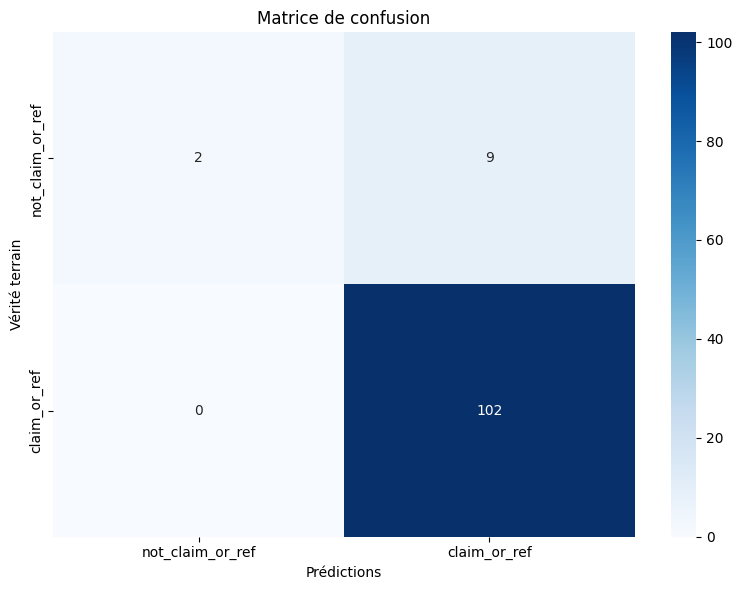

              precision    recall  f1-score   support

         0.0       1.00      0.18      0.31        11
         1.0       0.92      1.00      0.96       102

    accuracy                           0.92       113
   macro avg       0.96      0.59      0.63       113
weighted avg       0.93      0.92      0.89       113



In [27]:
def plot_confusion_matrix(cm, classes, title='Matrice de confusion', cmap=plt.cm.Blues):
    """
    Affiche la matrice de confusion.
    
    Parameters:
    - cm (array-like): Matrice de confusion (2D numpy array).
    - classes (list of str): Liste des noms des classes correspondant aux dimensions de la matrice.
    - title (str): Titre du graphique (par défaut 'Matrice de confusion').
    - cmap (matplotlib.colors.Colormap): Carte des couleurs à utiliser pour le graphique (par défaut plt.cm.Blues).
    """
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, xticklabels=classes, yticklabels=classes)
    plt.title(title)
    plt.ylabel('Vérité terrain')
    plt.xlabel('Prédictions')
    plt.tight_layout()
    plt.show()
    


conf = confusion_matrix(y_test, y_pred)

plot_confusion_matrix(conf, ['not_claim_or_ref', 'claim_or_ref'])
print(classification_report(y_test, y_pred))

In [ ]:
print(new_df.loc[new_df["claimref"] == 1.0, ["claimref"]].count())
print(new_df.loc[new_df["claimref"] == 0.0, ["claimref"]].count())
# Mauvais DataFrame: pas assez de données pour claimref != 0.0

claimref    342
dtype: int64
claimref    33
dtype: int64
